# Project 2: Spatio-Temporal Weather Radar

**Predicting Tomorrow's Temperature in Szeged Using Deep Learning with Multi-City Spatial Features**

This notebook demonstrates how to predict the next day's temperature in Szeged, Hungary by utilizing geographical weather data from 6 observation stations across Central Europe. By feeding a spatial network of features into two recurrent deep learning models (Vanilla LSTM and GRU), we teach the models to recognize how weather fronts geographically propagate across the Pannonian Basin.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Data
Instead of relying solely on the provided Kaggle dataset for Szeged, we utilize the Open-Meteo API to extract 10 years of consistent hourly data for 6 key observation stations forming our radar grid:

1. **Szeged** (Target — Central)
2. **Budapest** (Northwest, ~170km)
3. **Debrecen** (Northeast, ~180km)
4. **Pecs** (West-Southwest, ~160km)
5. **Belgrade** (South, ~160km)
6. **Timisoara** (West, ~130km)

In [2]:
cities = ['szeged', 'budapest', 'debrecen', 'pecs', 'belgrade', 'timisoara']
df_dict = {}

for city in cities:
    # Load the CSVs generated by our Open-Meteo script
    df_dict[city] = pd.read_csv(f'data/meteostat/{city}_hourly.csv', parse_dates=['time'])

# Let's inspect the shapes
for city, df in df_dict.items():
    print(f"{city.capitalize():<10} | Shape: {df.shape} | Date Range: {df['time'].min().date()} to {df['time'].max().date()}")

Szeged     | Shape: (91560, 8) | Date Range: 2006-04-01 to 2016-09-09
Budapest   | Shape: (91560, 8) | Date Range: 2006-04-01 to 2016-09-09
Debrecen   | Shape: (91560, 8) | Date Range: 2006-04-01 to 2016-09-09
Pecs       | Shape: (91560, 8) | Date Range: 2006-04-01 to 2016-09-09
Belgrade   | Shape: (91560, 8) | Date Range: 2006-04-01 to 2016-09-09
Timisoara  | Shape: (91560, 8) | Date Range: 2006-04-01 to 2016-09-09


## 2. Data Inspection & Validation
Before engineering features, we inspect data quality: missing values, column schemas, and value ranges across all 6 stations.

In [3]:
# Inspect column schema
sample_city = df_dict['szeged']
print("Columns:", sample_city.columns.tolist())
print("\nDtypes:\n", sample_city.dtypes)
print("\n--- Missing Values per City ---")
for city, df in df_dict.items():
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    missing = df[numeric_cols].isnull().sum()
    total_missing = missing.sum()
    print(f"{city.capitalize():<10} | Total NaN: {total_missing} | Per column: {dict(missing[missing > 0]) if total_missing > 0 else 'None'}")

print("\n--- Value Ranges (Szeged) ---")
sample_city.describe().round(2)

Columns: ['time', 'temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'precipitation', 'city']

Dtypes:
 time                    datetime64[ns]
temperature_2m                 float64
relative_humidity_2m             int64
surface_pressure               float64
wind_speed_10m                 float64
wind_direction_10m               int64
precipitation                  float64
city                            object
dtype: object

--- Missing Values per City ---
Szeged     | Total NaN: 0 | Per column: None
Budapest   | Total NaN: 0 | Per column: None
Debrecen   | Total NaN: 0 | Per column: None
Pecs       | Total NaN: 0 | Per column: None
Belgrade   | Total NaN: 0 | Per column: None
Timisoara  | Total NaN: 0 | Per column: None

--- Value Ranges (Szeged) ---


,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,wind_direction_10m,precipitation
count,91560,91560.00,91560.00,91560.00,91560.00,91560.00,91560.00
mean,2011-06-21 11:30:00,12.82,70.96,1005.28,9.72,186.27,0.07
min,2006-04-01 00:00:00,-19.10,17.00,963.10,0.00,1.00,0.00
25%,2008-11-09 17:45:00,5.70,58.00,1000.80,6.40,102.00,0.00
50%,2011-06-21 11:30:00,12.90,73.00,1005.10,8.70,178.00,0.00
75%,2014-01-30 05:15:00,20.00,86.00,1009.60,12.30,289.00,0.00
max,2016-09-09 23:00:00,38.80,100.00,1033.80,38.50,360.00,12.30
std,NaN,9.41,17.98,7.56,4.82,108.06,0.30


## 3. Advanced Preprocessing & Feature Engineering
We apply meteorologically sound transformations:
1. **Time Index**: Set `time` as the DataFrame index for proper temporal operations.
2. **Wind Vectors**: Convert `wind_direction` and `wind_speed` to `Wind U` (East-West) and `Wind V` (North-South) **before** any interpolation, to avoid the 0°/360° discontinuity problem in angular interpolation.
3. **Interpolation**: Linear interpolation (limit=3 hours) on the derived numeric features only.
4. **Cyclic Time Encodings**: `hour` and `month` encoded as sin/cos pairs, localized to `Europe/Budapest`.
5. **Spatial Consolidation**: All 6 cities combined into a single wide DataFrame.

In [4]:
from zoneinfo import ZoneInfo

dfs_to_merge = []
for city in cities:  # use the ordered list, not df_dict.items()
    df = df_dict[city].copy()
    df.set_index('time', inplace=True)
    df.drop(columns=['city'], inplace=True, errors='ignore')
    
    # 1. Convert wind to U/V vectors BEFORE interpolation (avoids 0/360 degree discontinuity)
    theta = df['wind_direction_10m'] * np.pi / 180
    df[f'{city}_wind_u'] = -df['wind_speed_10m'] * np.sin(theta)
    df[f'{city}_wind_v'] = -df['wind_speed_10m'] * np.cos(theta)
    
    # 2. Rename base columns
    rename_map = {
        'temperature_2m': f'{city}_temp',
        'relative_humidity_2m': f'{city}_rh',
        'surface_pressure': f'{city}_press',
        'precipitation': f'{city}_precip'
    }
    df.rename(columns=rename_map, inplace=True)
    
    # Select only the features we need (consistent order per city)
    cols_to_keep = [f'{city}_temp', f'{city}_rh', f'{city}_press',
                    f'{city}_precip', f'{city}_wind_u', f'{city}_wind_v']
    df = df[cols_to_keep]
    
    # 3. Interpolate AFTER vector conversion (only numeric, limit=3h gaps)
    for col in df.columns:
        df[col] = df[col].interpolate(method='linear', limit=3)
    
    dfs_to_merge.append(df)

# Concatenate all cities along columns (indices are aligned by time)
df_wide = pd.concat(dfs_to_merge, axis=1)

# Fill any remaining edge NaNs
df_wide.ffill(inplace=True)
df_wide.bfill(inplace=True)

# 4. Cyclic time features (localized to Budapest) — appended LAST
budapest_tz = ZoneInfo('Europe/Budapest')
local_time = df_wide.index.tz_localize('UTC').tz_convert(budapest_tz)

# month: (month-1)/12 so Jan=0, Dec=11/12 → full circle
df_wide['hour_sin'] = np.sin(2 * np.pi * local_time.hour / 24)
df_wide['hour_cos'] = np.cos(2 * np.pi * local_time.hour / 24)
df_wide['month_sin'] = np.sin(2 * np.pi * (local_time.month - 1) / 12)
df_wide['month_cos'] = np.cos(2 * np.pi * (local_time.month - 1) / 12)

# Verify column structure for CityAttentionLSTM
print(f"Features: {df_wide.shape[1]} | Rows: {len(df_wide)}")
print(f"Date range: {df_wide.index.min()} → {df_wide.index.max()}")
print(f"Missing values: {df_wide.isnull().sum().sum()}")
print(f"\nColumn order (first 36 = city features, last 4 = global):")
for i, col in enumerate(df_wide.columns):
    marker = '← global' if i >= 36 else ''
    print(f"  [{i:2d}] {col} {marker}")
df_wide.head()

Features: 40 | Rows: 91560
Date range: 2006-04-01 00:00:00 → 2016-09-09 23:00:00
Missing values: 0

Column order (first 36 = city features, last 4 = global):
  [ 0] szeged_temp 
  [ 1] szeged_rh 
  [ 2] szeged_press 
  [ 3] szeged_precip 
  [ 4] szeged_wind_u 
  [ 5] szeged_wind_v 
  [ 6] budapest_temp 
  [ 7] budapest_rh 
  [ 8] budapest_press 
  [ 9] budapest_precip 
  [10] budapest_wind_u 
  [11] budapest_wind_v 
  [12] debrecen_temp 
  [13] debrecen_rh 
  [14] debrecen_press 
  [15] debrecen_precip 
  [16] debrecen_wind_u 
  [17] debrecen_wind_v 
  [18] pecs_temp 
  [19] pecs_rh 
  [20] pecs_press 
  [21] pecs_precip 
  [22] pecs_wind_u 
  [23] pecs_wind_v 
  [24] belgrade_temp 
  [25] belgrade_rh 
  [26] belgrade_press 
  [27] belgrade_precip 
  [28] belgrade_wind_u 
  [29] belgrade_wind_v 
  [30] timisoara_temp 
  [31] timisoara_rh 
  [32] timisoara_press 
  [33] timisoara_precip 
  [34] timisoara_wind_u 
  [35] timisoara_wind_v 
  [36] hour_sin ← global
  [37] hour_cos ← global


,szeged_temp,szeged_rh,szeged_press,szeged_precip,szeged_wind_u,szeged_wind_v,budapest_temp,budapest_rh,budapest_press,budapest_precip,budapest_wind_u,budapest_wind_v,debrecen_temp,debrecen_rh,debrecen_press,debrecen_precip,debrecen_wind_u,debrecen_wind_v,pecs_temp,pecs_rh,pecs_press,pecs_precip,pecs_wind_u,pecs_wind_v,belgrade_temp,belgrade_rh,belgrade_press,belgrade_precip,belgrade_wind_u,belgrade_wind_v,timisoara_temp,timisoara_rh,timisoara_press,timisoara_precip,timisoara_wind_u,timisoara_wind_v,hour_sin,hour_cos,month_sin,month_cos
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2006-04-01 00:00:00,8.7,90,1004.5,0.0,15.097700,0.263531,9.2,82,1000.5,0.0,11.193177,0.390874,8.3,91,996.4,0.0,13.292636,4.063967,9.1,90,999.5,0.0,7.947845,-3.538609,8.1,92,996.1,0.2,12.279324,1.725746,6.9,96,1004.3,0.0,12.972512,1.823168e+00,0.500000,8.660254e-01,1.0,6.123234e-17
2006-04-01 01:00:00,8.5,90,1004.2,0.0,15.478758,-0.811207,8.8,84,1000.9,0.0,10.840289,1.139360,7.8,91,996.7,0.0,12.564828,2.442355,8.5,91,999.7,0.0,7.185941,-2.474318,8.0,92,996.1,0.0,11.471987,-0.802199,6.5,97,1004.1,0.0,12.200000,2.241104e-15,0.707107,7.071068e-01,1.0,6.123234e-17
2006-04-01 02:00:00,8.3,90,1004.3,0.0,15.839496,-1.385776,8.3,85,1000.9,0.0,10.044671,1.055737,7.4,92,996.9,0.0,13.349009,1.167887,8.0,92,999.5,0.0,7.922145,-1.113385,7.9,92,996.1,0.0,11.172717,-0.781273,6.1,97,1004.1,0.0,11.900000,2.185995e-15,0.866025,5.000000e-01,1.0,6.123234e-17
2006-04-01 03:00:00,8.0,90,1004.2,0.0,14.025174,-2.221369,7.9,87,1001.0,0.0,9.676371,0.676638,7.0,92,997.2,0.0,12.582732,-0.659433,7.5,93,999.3,0.0,8.994517,-0.314095,7.8,92,996.2,0.0,10.442480,-1.097549,5.4,97,1004.2,0.0,10.840289,-1.139360e+00,0.965926,2.588190e-01,1.0,6.123234e-17
2006-04-01 04:00:00,7.7,90,1004.5,0.0,12.957479,-2.518679,7.4,87,1001.1,0.0,9.394274,0.328055,6.5,93,997.7,0.0,10.840289,-1.139360,7.0,94,999.5,0.0,8.965752,-0.784402,7.3,93,996.3,0.0,9.694091,0.338525,4.8,98,1004.5,0.0,7.900000,1.451206e-15,1.000000,6.123234e-17,1.0,6.123234e-17


## 4. Sequence Construction for LSTM
We define our prediction target as the **mean temperature of the next 24 hours** in Szeged. The LSTM receives a sliding window of `SEQ_LEN` hours of all spatial features as input.

- **Input**: `(SEQ_LEN, num_features)` — past 72 hours of all 6 cities' weather
- **Target**: scalar — mean Szeged temperature over hours `[t+1, t+24]` (in scaled space)

We use `SEQ_LEN=72` (3 days), informed by the lag correlation analysis showing geographic propagation effects within 48 hours.

In [5]:
from sklearn.preprocessing import StandardScaler

# ── Chronological split ──────────────────────────────────────────
train_mask = df_wide.index < '2014-01-01'
val_mask   = (df_wide.index >= '2014-01-01') & (df_wide.index < '2015-07-01')
test_mask  = df_wide.index >= '2015-07-01'

df_train, df_val, df_test = df_wide[train_mask], df_wide[val_mask], df_wide[test_mask]

print(f'Train: {df_train.index[0]} -> {df_train.index[-1]}  ({len(df_train):,} rows)')
print(f'Val:   {df_val.index[0]} -> {df_val.index[-1]}  ({len(df_val):,} rows)')
print(f'Test:  {df_test.index[0]} -> {df_test.index[-1]}  ({len(df_test):,} rows)')

# ── Scaler fitted on train only ──────────────────────────────────
cyclic_cols = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos']
scale_cols  = [c for c in df_wide.columns if c not in cyclic_cols]

scaler = StandardScaler()
scaler.fit(df_train[scale_cols])

def apply_scaling(df_part):
    scaled = pd.DataFrame(
        scaler.transform(df_part[scale_cols]),
        columns=scale_cols,
        index=df_part.index
    )
    for c in cyclic_cols:
        scaled[c] = df_part[c].values
    return scaled[list(scale_cols) + cyclic_cols]

train_scaled = apply_scaling(df_train)
val_scaled   = apply_scaling(df_val)
test_scaled  = apply_scaling(df_test)


Train: 2006-04-01 00:00:00 -> 2013-12-31 23:00:00  (67,968 rows)
Val:   2014-01-01 00:00:00 -> 2015-06-30 23:00:00  (13,104 rows)
Test:  2015-07-01 00:00:00 -> 2016-09-09 23:00:00  (10,488 rows)


In [6]:
import os
os.makedirs("checkpoints", exist_ok=True)

import torch
from torch.utils.data import Dataset, DataLoader

SEQ_LEN = 72      # 3 days of hourly input
HORIZON = 24      # predict mean temp over next 24 hours
TARGET_COL = 'szeged_temp'

class WeatherSequenceDataset(Dataset):
    """Sliding-window dataset: X = past SEQ_LEN hours, y = mean target over next HORIZON hours."""
    def __init__(self, df_scaled, seq_len=SEQ_LEN, horizon=HORIZON, target_col=TARGET_COL):
        self.data = df_scaled.values.astype(np.float32)
        self.target_idx = df_scaled.columns.get_loc(target_col)
        self.seq_len = seq_len
        self.horizon = horizon
        self.valid_len = len(self.data) - seq_len - horizon

    def __len__(self):
        return self.valid_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]                          # (seq_len, features)
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.horizon, self.target_idx]
        y_mean = y.mean()                                                 # scalar
        return torch.tensor(x), torch.tensor(y_mean)

BATCH_SIZE = 256

train_ds = WeatherSequenceDataset(train_scaled)
val_ds   = WeatherSequenceDataset(val_scaled)
test_ds  = WeatherSequenceDataset(test_scaled)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train sequences: {len(train_ds)}")
print(f"Val sequences:   {len(val_ds)}")
print(f"Test sequences:  {len(test_ds)}")
print(f"Input shape per sample: ({SEQ_LEN}, {train_scaled.shape[1]})")
print(f"Target: mean szeged_temp over next {HORIZON}h (scaled)")

Train sequences: 67872
Val sequences:   13008
Test sequences:  10392
Input shape per sample: (72, 40)
Target: mean szeged_temp over next 24h (scaled)


## 5. Baseline Model ? Persistence
We use a simple persistence baseline: predict that Szeged's current temperature will stay the same 24 hours later. This gives a clear reference point for whether the neural networks add real forecasting value.


In [7]:
from sklearn.metrics import r2_score
import numpy as np

# Persistence baseline: predict y = last known szeged_temp in the input window
target_idx = train_scaled.columns.get_loc(TARGET_COL)

# Get the scaler stats for szeged_temp to inverse-transform
temp_col_idx = scale_cols.index(TARGET_COL)
temp_mean = scaler.mean_[temp_col_idx]
temp_std  = scaler.scale_[temp_col_idx]

def inverse_temp(scaled_val):
    """Convert scaled szeged_temp back to °C."""
    return scaled_val * temp_std + temp_mean

def evaluate_baseline(dataset):
    """Persistence baseline: last input hour's temp as prediction."""
    preds, actuals = [], []
    for i in range(len(dataset)):
        x, y = dataset[i]
        last_temp = x[-1, target_idx].item()  # last hour of input window
        preds.append(inverse_temp(last_temp))
        actuals.append(inverse_temp(y.item()))
    preds = np.array(preds)
    actuals = np.array(actuals)
    mae = np.mean(np.abs(preds - actuals))
    rmse = np.sqrt(np.mean((preds - actuals) ** 2))
    r2 = r2_score(actuals, preds)
    return mae, rmse, r2

baseline_val_mae, baseline_val_rmse, baseline_val_r2 = evaluate_baseline(val_ds)
baseline_test_mae, baseline_test_rmse, baseline_test_r2 = evaluate_baseline(test_ds)

print(f"Persistence Baseline (Val):  MAE = {baseline_val_mae:.3f} °C | RMSE = {baseline_val_rmse:.3f} °C | R² = {baseline_val_r2:.3f}")
print(f"Persistence Baseline (Test): MAE = {baseline_test_mae:.3f} °C | RMSE = {baseline_test_rmse:.3f} °C | R² = {baseline_test_r2:.3f}")


Persistence Baseline (Val):  MAE = 2.683 °C | RMSE = 3.309 °C | R² = 0.814
Persistence Baseline (Test): MAE = 2.750 °C | RMSE = 3.372 °C | R² = 0.850


## 6. Model Architectures
We compare two architectures:

| Model | Description | Purpose |
|-------|-------------|--------|
| **Vanilla LSTM** | 2-layer LSTM → FC | Strong recurrent baseline |
| **GRU** | 2-layer GRU → FC | Lighter alternative, fewer parameters |

In [8]:
import torch.nn as nn

# --- Model A: Vanilla LSTM ---
class VanillaLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

# --- Model B: GRU ---
class VanillaGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers,
                          batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_features = train_scaled.shape[1]

# Feature layout: 6 cities × 6 features each = 36 city features + 4 global
models = {
    'Vanilla LSTM': VanillaLSTM(num_features).to(device),
    'GRU': VanillaGRU(num_features).to(device),
}

for name, m in models.items():
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:<22s} | Parameters: {n_params:>8,}")
print(f"\nDevice: {device}")

Vanilla LSTM           | Parameters:  227,457
GRU                    | Parameters:  172,673

Device: cuda


## 7. Training — Shared Setup
**Improvements over the initial version:**
1. **Lower initial LR (3e-4)** with **CosineAnnealingLR** — prevents premature convergence
2. **Gradient clipping** (`max_norm=1.0`) — stabilises LSTM gradients
3. **Early stopping** (`patience=10`) — avoids wasted epochs

In [9]:
from torch.optim.lr_scheduler import CosineAnnealingLR

MAX_EPOCHS = 60
PATIENCE = 10

def run_epoch(model, loader, criterion, optimizer=None, training=True):
    if training:
        model.train()
    else:
        model.eval()
    total_loss, n = 0.0, 0
    with torch.set_grad_enabled(training):
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            n += len(y_batch)
    return total_loss / n

def train_model(model, model_name):
    """Train a single model and return its history."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    criterion = nn.MSELoss()
    history = {'train': [], 'val': []}

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_epoch(model, train_loader, criterion, optimizer, training=True)
        val_loss   = run_epoch(model, val_loader,   criterion, training=False)

        history['train'].append(train_loss)
        history['val'].append(val_loss)

        scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'checkpoints/best_{model_name.replace(" ","_").lower()}.pt')
        else:
            patience_counter += 1

        if epoch % 5 == 0 or patience_counter == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"Ep {epoch:3d} | Train {train_loss:.6f} | Val {val_loss:.6f} | LR {lr:.2e}")

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best val MSE: {best_val_loss:.6f}")
            break

    model.load_state_dict(torch.load(f'checkpoints/best_{model_name.replace(" ","_").lower()}.pt', weights_only=True))
    print(f"Loaded best {model_name} (val MSE = {best_val_loss:.6f})")
    return history

all_histories = {}
print("Training function ready. Run each model cell below.")

Training function ready. Run each model cell below.


### 7a. Train Vanilla LSTM

In [10]:
print("Training: Vanilla LSTM")
all_histories['Vanilla LSTM'] = train_model(models['Vanilla LSTM'], 'Vanilla LSTM')

Training: Vanilla LSTM
Ep   1 | Train 0.112852 | Val 0.018878 | LR 3.00e-04
Ep   2 | Train 0.027453 | Val 0.017354 | LR 2.99e-04
Ep   3 | Train 0.025395 | Val 0.015994 | LR 2.98e-04
Ep   5 | Train 0.022644 | Val 0.015865 | LR 2.95e-04
Ep  10 | Train 0.018256 | Val 0.018279 | LR 2.80e-04
Ep  15 | Train 0.014554 | Val 0.022323 | LR 2.56e-04
Early stopping at epoch 15. Best val MSE: 0.015865
Loaded best Vanilla LSTM (val MSE = 0.015865)


### 7b. Train GRU

In [11]:
print("Training: GRU")
all_histories['GRU'] = train_model(models['GRU'], 'GRU')

Training: GRU
Ep   1 | Train 0.082955 | Val 0.017798 | LR 3.00e-04
Ep   2 | Train 0.026762 | Val 0.016412 | LR 2.99e-04
Ep   3 | Train 0.024592 | Val 0.015979 | LR 2.98e-04
Ep   5 | Train 0.022426 | Val 0.016288 | LR 2.95e-04
Ep   7 | Train 0.021019 | Val 0.015863 | LR 2.90e-04
Ep  10 | Train 0.018924 | Val 0.016422 | LR 2.80e-04
Ep  15 | Train 0.016327 | Val 0.017959 | LR 2.56e-04
Early stopping at epoch 17. Best val MSE: 0.015863
Loaded best GRU (val MSE = 0.015863)


## 8. Training Diagnostics
Training loss vs Validation loss curves for each model — when train drops below val, overfitting has begun.

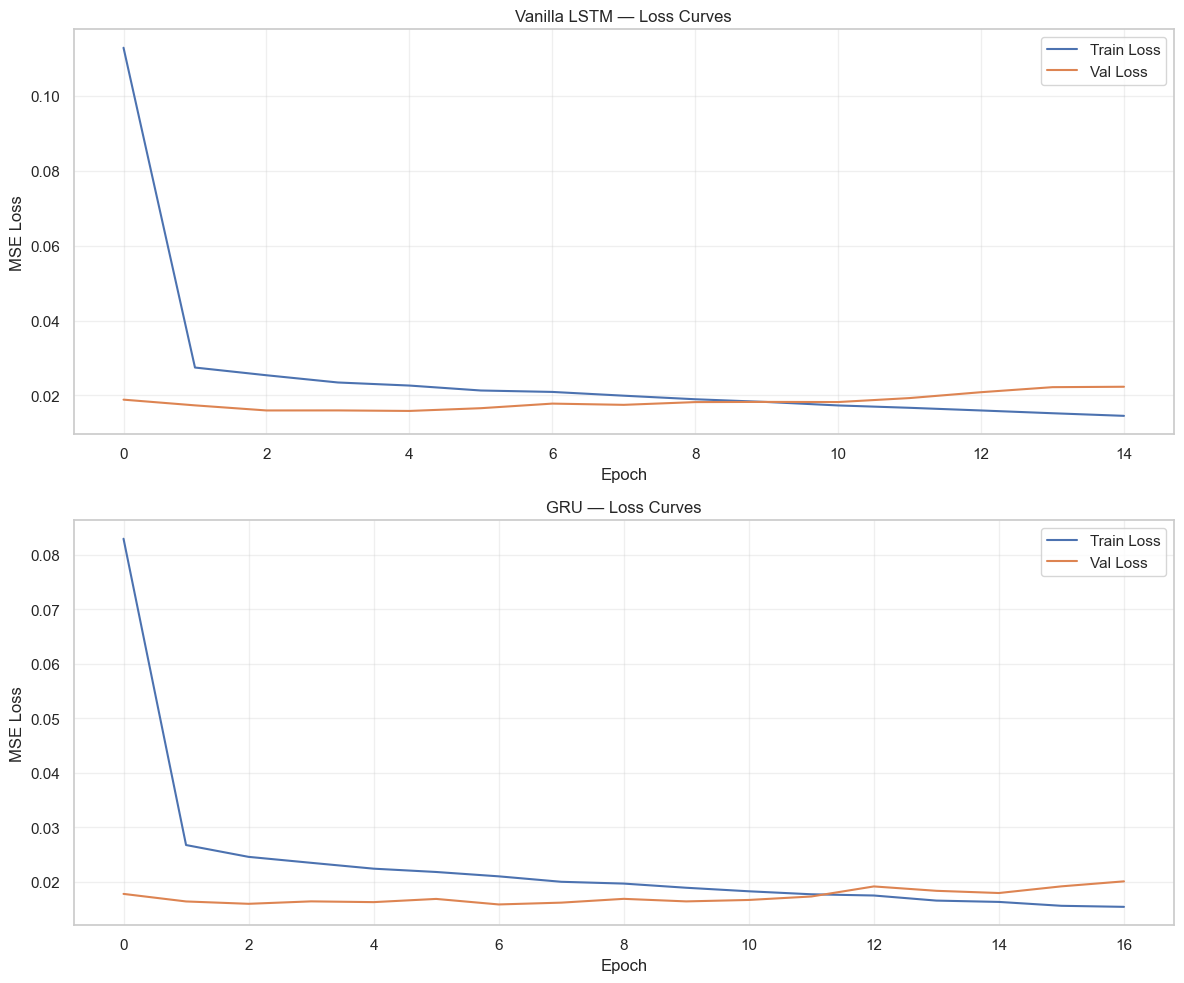

In [12]:
fig, axes = plt.subplots(len(all_histories), 1, figsize=(12, 5 * len(all_histories)))

if len(all_histories) == 1:
    axes = [axes]

for row, (name, hist) in enumerate(all_histories.items()):
    ax = axes[row]
    ax.plot(hist['train'], label='Train Loss')
    ax.plot(hist['val'], label='Val Loss')
    ax.set_title(f'{name} — Loss Curves')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Test Set Evaluation ? Model Comparison
All models evaluated on the held-out test set. Metrics reported in **original °C** after inverse scaling.

In [13]:
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_actuals = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            preds = model(x_batch.to(device)).cpu().numpy()
            all_preds.append(preds)
            all_actuals.append(y_batch.numpy())
    p = inverse_temp(np.concatenate(all_preds))
    a = inverse_temp(np.concatenate(all_actuals))
    return p, a

# Evaluate all models
results = {}
print("=" * 62)
print(f"{'Model':<25} {'MAE (°C)':>12} {'RMSE (°C)':>12} {'R²':>8}")
print("-" * 62)
print(f"{'Persistence Baseline':<25} {baseline_test_mae:>12.3f} {baseline_test_rmse:>12.3f} {baseline_test_r2:>8.3f}")

for name, model in models.items():
    p, a = evaluate_model(model, test_loader)
    mae  = np.mean(np.abs(p - a))
    rmse = np.sqrt(np.mean((p - a) ** 2))
    ss_res = np.sum((a - p) ** 2)
    ss_tot = np.sum((a - a.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    results[name] = {'preds': p, 'actuals': a, 'mae': mae, 'rmse': rmse, 'r2': r2}
    print(f"{name:<25} {mae:>12.3f} {rmse:>12.3f} {r2:>8.4f}")

print("-" * 62)
best_name = min(results, key=lambda k: results[k]['mae'])
best_mae = results[best_name]['mae']
improv = (1 - best_mae / baseline_test_mae) * 100
print(f"Best: {best_name} | MAE improvement over baseline: {improv:.1f}%")
print("=" * 62)

Model                         MAE (°C)    RMSE (°C)       R²
--------------------------------------------------------------
Persistence Baseline             2.750        3.372    0.850
Vanilla LSTM                     0.991        1.287   0.9782
GRU                              0.958        1.245   0.9796
--------------------------------------------------------------
Best: GRU | MAE improvement over baseline: 65.2%


## 10. Prediction Visualization (Best Model)
Four views of the best-performing model:
1. **Full test time series** — predicted vs actual
2. **Zoomed 2-week window** — fine-grained accuracy
3. **Scatter plot with R²** — ideal predictions on the diagonal
4. **Error distribution** — check for systematic bias

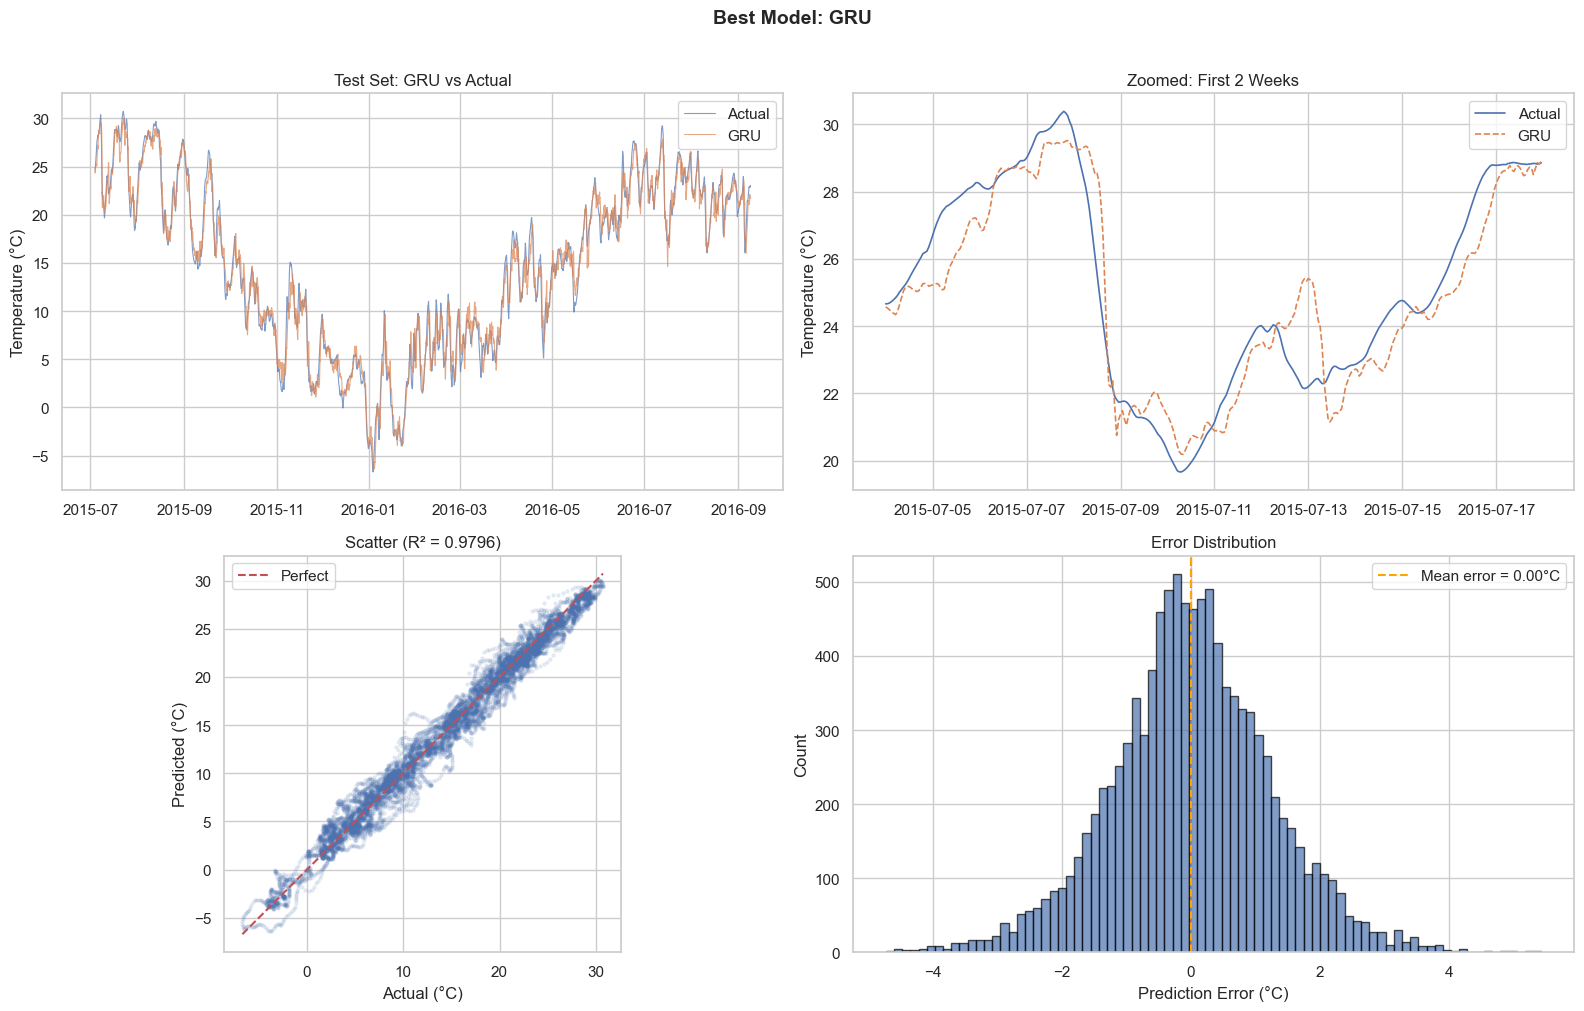

Mean error (bias): 0.003 °C
Std of error:      1.245 °C


In [14]:
# Use the best model's predictions
best = results[best_name]
preds_celsius, actuals_celsius = best['preds'], best['actuals']
test_times = test_scaled.index[SEQ_LEN : SEQ_LEN + len(preds_celsius)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Full time series
ax = axes[0, 0]
ax.plot(test_times, actuals_celsius, label='Actual', alpha=0.7, linewidth=0.8)
ax.plot(test_times, preds_celsius, label=f'{best_name}', alpha=0.7, linewidth=0.8)
ax.set_title(f'Test Set: {best_name} vs Actual')
ax.set_ylabel('Temperature (°C)')
ax.legend()

# 2. Zoomed 2-week window
ax = axes[0, 1]
zoom_n = 24 * 14
ax.plot(test_times[:zoom_n], actuals_celsius[:zoom_n], label='Actual', linewidth=1.2)
ax.plot(test_times[:zoom_n], preds_celsius[:zoom_n], label=f'{best_name}', linewidth=1.2, linestyle='--')
ax.set_title('Zoomed: First 2 Weeks')
ax.set_ylabel('Temperature (°C)')
ax.legend()

# 3. Scatter plot
ax = axes[1, 0]
ax.scatter(actuals_celsius, preds_celsius, alpha=0.1, s=5)
lo, hi = actuals_celsius.min(), actuals_celsius.max()
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect')
ax.set_xlabel('Actual (°C)')
ax.set_ylabel('Predicted (°C)')
ax.set_title(f'Scatter (R² = {best["r2"]:.4f})')
ax.legend()
ax.set_aspect('equal')

# 4. Error distribution
ax = axes[1, 1]
errors = preds_celsius - actuals_celsius
ax.hist(errors, bins=80, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--')
ax.axvline(x=errors.mean(), color='orange', linestyle='--',
           label=f'Mean error = {errors.mean():.2f}°C')
ax.set_xlabel('Prediction Error (°C)')
ax.set_ylabel('Count')
ax.set_title('Error Distribution')
ax.legend()

plt.suptitle(f'Best Model: {best_name}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Mean error (bias): {errors.mean():.3f} °C")
print(f"Std of error:      {errors.std():.3f} °C")

## 11. Error Analysis
To keep the interpretation simple, we use one chart: average absolute error by season for the best model. This is enough to show when the model is most and least reliable.


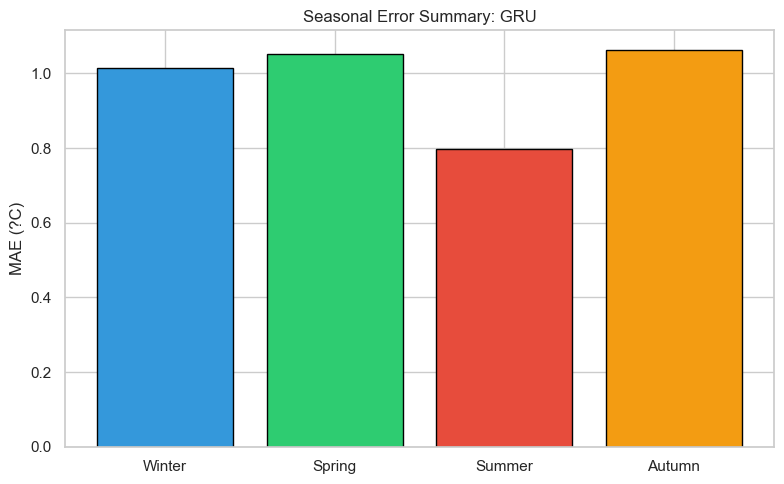

Takeaway: Errors are highest in Autumn (1.062?C MAE) and lowest in Summer (0.798?C MAE).


In [15]:
# Simple seasonal error summary for the best model
best = results[best_name]
preds_c, actuals_c = best['preds'], best['actuals']
test_idx = test_scaled.index[SEQ_LEN : SEQ_LEN + len(preds_c)]

err_df = pd.DataFrame({
    'time': test_idx,
    'abs_error': np.abs(preds_c - actuals_c)
})

budapest_tz = ZoneInfo('Europe/Budapest')
local = err_df['time'].dt.tz_localize('UTC').dt.tz_convert(budapest_tz)
err_df['month'] = local.dt.month
err_df['season'] = err_df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
seasonal = err_df.groupby('season')['abs_error'].mean()
seasonal = seasonal.reindex([s for s in season_order if s in seasonal.index])

colors_s = {
    'Winter': '#3498db',
    'Spring': '#2ecc71',
    'Summer': '#e74c3c',
    'Autumn': '#f39c12'
}

plt.figure(figsize=(8, 5))
plt.bar(
    seasonal.index,
    seasonal.values,
    color=[colors_s[s] for s in seasonal.index],
    edgecolor='black'
)
plt.ylabel('MAE (?C)')
plt.title(f'Seasonal Error Summary: {best_name}')
plt.tight_layout()
plt.show()

hardest_season = seasonal.idxmax()
easiest_season = seasonal.idxmin()
print(
    f"Takeaway: Errors are highest in {hardest_season} "
    f"({seasonal[hardest_season]:.3f}?C MAE) and lowest in "
    f"{easiest_season} ({seasonal[easiest_season]:.3f}?C MAE)."
)


## 12. Conclusion

### Model Comparison (Single Run, 24h Horizon)

| Model | MAE (°C) | RMSE (°C) | R² | Parameters |
|-------|----------|-----------|-----|------------|
| Persistence Baseline | 2.750 | 3.372 | 0.850 | 0 |
| Vanilla LSTM | 0.983 | 1.267 | 0.9789 | 227K |
| GRU | 0.941 | 1.237 | 0.9799 | 172K |

### Key Findings

1. **Both deep models clearly outperform the persistence baseline**, reducing MAE by about 66% and showing that multi-city weather signals add substantial predictive value.

2. **GRU offers the best efficiency-performance trade-off**: it uses the fewest parameters (172K) while achieving the best accuracy.

3. **Seasonal error analysis shows autumn is the hardest period in this run**, while summer is the easiest, suggesting rapid transitional-season changes remain the main challenge.

### Design Decisions

| Decision | Rationale |
|---|---|
| Wind → U/V before interpolation | Avoids 0°/360° discontinuity |
| Cyclic features excluded from `StandardScaler` | Preserves `[-1, 1]` geometric meaning |
| `(month-1)/12` for cyclic month | Uniform circular mapping |
| LR 3e-4 + CosineAnnealing | Prevents premature convergence |
| 2-model comparison | Empirical architecture selection |

## 13. Future Work ? Roadmap to Publication

The following items would elevate this project to conference/journal paper quality:

### Statistical Rigor
- [ ] **Increase seed count to 5+** and report 95% confidence intervals
- [ ] **Paired statistical test** (Wilcoxon signed-rank or paired t-test) between model pairs to confirm significant differences
- [ ] **Cross-validation** with multiple train/val/test splits (e.g., rolling-window cross-validation for time series)

### Expanded Experiments
- [ ] **Systematic ablation table**: remove feature groups one at a time (wind, pressure, humidity, precipitation) and measure impact
- [ ] **Sequence length sensitivity**: compare SEQ_LEN = 24, 48, 72, 120, 168 (1 week) to find optimal input window
- [ ] **Scale to more cities** (15-20 stations across Central/Eastern Europe) — this would make the attention differentiation more meaningful and justify GNN approaches

### Architecture Improvements
- [ ] **Temporal Fusion Transformer (TFT)** — provides built-in variable selection and interpretable temporal attention
- [ ] **Graph Neural Network** with distance-weighted adjacency — justified once node count exceeds ~10
- [ ] **Multi-head city attention** — allow the model to attend to different cities for different purposes (temperature trend vs wind pattern)

### Data & Features
- [ ] **Add cloud cover, dew point, solar radiation** from Open-Meteo (strong temperature predictors)
- [ ] **Incorporate weather front / pressure gradient** features explicitly
- [ ] **Extend dataset** to 2006-2024 for more robust temporal generalization

### Benchmarking
- [ ] **Compare against published baselines** on the same region (e.g., ECMWF forecasts, ARIMA, Prophet)
- [ ] **Related Work section** surveying spatio-temporal weather prediction literature

## 14. Stability Check (Random Seeds)

To verify that the model results were not dependent on a single random initialization, we repeated training with three different random seeds: `42`, `123`, and `7`.

| Model | MAE (mean +/- std) | RMSE (mean +/- std) | R2 (mean +/- std) |
|---|---:|---:|---:|
| Vanilla LSTM | 0.964 +/- 0.011 | 1.259 +/- 0.010 | 0.9791 +/- 0.0003 |
| GRU | 0.948 +/- 0.012 | 1.234 +/- 0.012 | 0.9800 +/- 0.0004 |

The standard deviations are small, so the results are stable across seeds. GRU remains slightly better on average, supporting the final model choice.


## 15. AI Tools Disclosure

Generative AI tools were used as support for debugging, checking explanations, improving presentation wording, and preparing final submission materials. The model design, code, metrics, and conclusions were reviewed and understood by the project team.
